# Amazon Sales EDA

## 1. Mục tiêu notebook

Notebook này dùng để khám phá bộ dữ liệu `Amazon Sale Report.csv` trước khi đưa logic phân tích vào backend của project AI Data Analyst Agent.

Mục tiêu chính:

- Hiểu cấu trúc dữ liệu.
- Kiểm tra chất lượng dữ liệu.
- Làm sạch dữ liệu bước đầu.
- Tạo feature phục vụ phân tích.
- Thực hiện EDA business.
- Rút ra các logic có thể chuyển thành reusable tools.

## 2. Import thư viện và cấu hình hiển thị

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

plt.style.use("seaborn-v0_8-whitegrid")

def format_inr_axis(axis):
    axis.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M"))


def add_bar_labels(ax, fmt="{:,.0f}", rotation=0):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, fontsize=8, rotation=rotation)


## 3. Load dữ liệu raw

In [2]:
DATA_PATH = "../data/raw/Amazon Sale Report.csv"

df_raw = pd.read_csv(DATA_PATH, low_memory = False)
df_raw.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,"400,081.00",IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,"560,085.00",IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,"410,210.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,"605,008.00",IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,"600,073.00",IN,NaN,False,NaN,NaN


In [3]:
df_raw.shape

(128975, 24)

## 4. Kiểm tra cấu trúc dữ liệu 

In [4]:
df_raw.columns.tolist()

['index',
 'Order ID',
 'Date',
 'Status',
 'Fulfilment',
 'Sales Channel ',
 'ship-service-level',
 'Style',
 'SKU',
 'Category',
 'Size',
 'ASIN',
 'Courier Status',
 'Qty',
 'currency',
 'Amount',
 'ship-city',
 'ship-state',
 'ship-postal-code',
 'ship-country',
 'promotion-ids',
 'B2B',
 'fulfilled-by',
 'Unnamed: 22']

In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [6]:
df_raw.dtypes

index                   int64
Order ID               object
Date                   object
Status                 object
Fulfilment             object
Sales Channel          object
ship-service-level     object
Style                  object
SKU                    object
Category               object
Size                   object
ASIN                   object
Courier Status         object
Qty                     int64
currency               object
Amount                float64
ship-city              object
ship-state             object
ship-postal-code      float64
ship-country           object
promotion-ids          object
B2B                      bool
fulfilled-by           object
Unnamed: 22            object
dtype: object

In [7]:
df_raw.head(10)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,"400,081.00",IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,"560,085.00",IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,"410,210.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,"605,008.00",IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,"600,073.00",IN,NaN,False,NaN,NaN
5,5,404-1490984-4578765,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264-KR-NP-XL,Set,XL,B08YN7XDSG,Shipped,1,INR,824.00,GHAZIABAD,UTTAR PRADESH,"201,102.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
6,6,408-5748499-6859555,04-30-22,Shipped,Amazon,Amazon.in,Expedited,J0095,J0095-SET-L,Set,L,B08CMHNWBN,Shipped,1,INR,653.00,CHANDIGARH,CHANDIGARH,"160,036.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
7,7,406-7807733-3785945,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3405,JNE3405-KR-S,kurta,S,B081WX4G4Q,Shipped,1,INR,399.00,HYDERABAD,TELANGANA,"500,032.00",IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
8,8,407-5443024-5233168,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,SET200,SET200-KR-NP-A-XXXL,Set,3XL,B08L91ZZXN,Cancelled,0,NaN,NaN,HYDERABAD,TELANGANA,"500,008.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
9,9,402-4393761-0311520,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3461,JNE3461-KR-XXL,kurta,XXL,B08B3XF5MH,Shipped,1,INR,363.00,Chennai,TAMIL NADU,"600,041.00",IN,NaN,False,NaN,NaN


In [8]:
df_raw.describe()

,index,Qty,Amount,ship-postal-code
count,"128,975.00","128,975.00","121,180.00","128,942.00"
mean,"64,487.00",0.90,648.56,"463,966.24"
std,"37,232.02",0.31,281.21,"191,476.76"
min,0.00,0.00,0.00,"110,001.00"
25%,"32,243.50",1.00,449.00,"382,421.00"
50%,"64,487.00",1.00,605.00,"500,033.00"
75%,"96,730.50",1.00,788.00,"600,024.00"
max,"128,974.00",15.00,"5,584.00","989,898.00"


In [9]:
df_raw.describe(include = 'object')

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,currency,ship-city,ship-state,ship-country,promotion-ids,fulfilled-by,Unnamed: 22
count,128975,128975,128975,128975,128975,128975,128975,128975,128975,128975,128975,122103,121180,128942,128942,128942,79822,39277,79925
unique,120378,91,13,2,2,2,1377,7195,9,11,7190,3,1,8955,69,1,5787,1,1
top,171-5057375-2831560,05-03-22,Shipped,Amazon,Amazon.in,Expedited,JNE3797,JNE3797-KR-L,Set,M,B09SDXFFQ1,Shipped,INR,BENGALURU,MAHARASHTRA,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,Easy Ship,False
freq,12,2085,77804,89698,128851,88615,4224,773,50284,22711,773,109487,121180,11217,22260,128942,46100,39277,79925


## 5. Ý nghĩa sơ bộ của các cột

Ghi chú thủ công sau khi quan sát dữ liệu:

- `Order ID`: mã đơn hàng.
- `Date`: ngày phát sinh đơn.
- `Status`: trạng thái đơn hàng.
- `Fulfilment`: hình thức fulfillment.
- `Sales Channel`: kênh bán hàng.
- `ship-service-level`: loại dịch vụ giao hàng.
- `Style`, `SKU`, `ASIN`: thông tin sản phẩm.
- `Category`: nhóm sản phẩm.
- `Size`: size sản phẩm.
- `Qty`: số lượng.
- `Amount`: giá trị đơn hàng.
- `ship-city`, `ship-state`, `ship-country`: thông tin giao hàng.
- `promotion-ids`: thông tin khuyến mãi.
- `B2B`: đơn B2B hay không.

## 6. Kiểm tra missing values

In [10]:
missing_count = df_raw.isna().sum().sort_values(ascending = False)
missing_percent = (df_raw.isna().mean()*100).round(2).sort_values(ascending = False)

missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
})

missing_summary

,missing_count,missing_percent
fulfilled-by,89698,69.55
promotion-ids,49153,38.11
Unnamed: 22,49050,38.03
currency,7795,6.04
Amount,7795,6.04
Courier Status,6872,5.33
ship-country,33,0.03
ship-city,33,0.03
ship-state,33,0.03
ship-postal-code,33,0.03


### Nhận xét nhanh về missing values

Từ output hiện tại:

- `fulfilled-by` missing khoảng 69.55%, nhưng đây có thể là do đơn do Amazon fulfilment nên không nhất thiết là lỗi dữ liệu.
- `promotion-ids` missing khoảng 38.11%, có thể hiểu là đơn không có promotion.
- `Amount` và `currency` cùng missing 7,795 dòng, cần kiểm tra vì đây là các cột quan trọng cho revenue analysis.
- Shipping location chỉ missing 33 dòng, ảnh hưởng nhỏ nhưng vẫn nên báo trong data quality warnings.
- `Unnamed: 22` không có ý nghĩa phân tích rõ ràng, nên loại khỏi dataset đã clean.

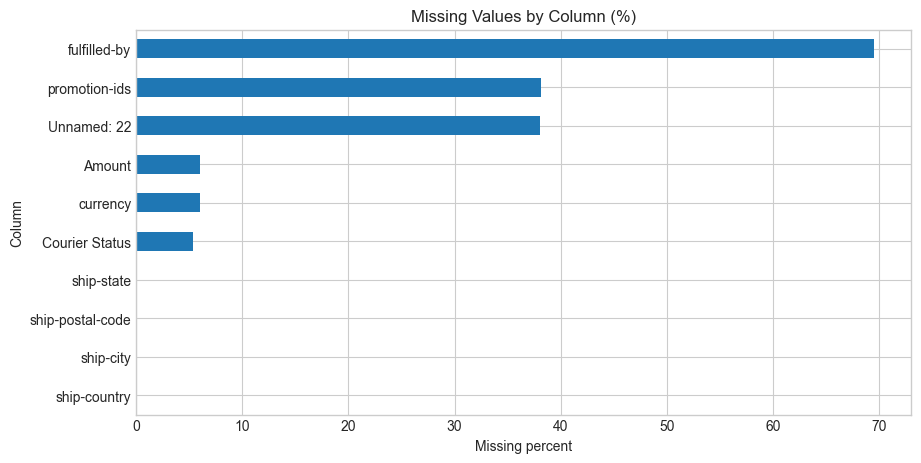

In [11]:
missing_plot = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_percent")

ax = missing_plot["missing_percent"].plot(
    kind="barh",
    figsize=(10, 5),
    title="Missing Values by Column (%)"
)
ax.set_xlabel("Missing percent")
ax.set_ylabel("Column")
plt.show()


## 7. Kiểm tra duplicates

In [12]:
df_raw.duplicated().sum()

np.int64(0)

In [13]:
df_raw["Order ID"].duplicated().sum()

np.int64(8597)

In [14]:
df_raw[df_raw["Order ID"].duplicated(keep=False)].head(20)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
37,37,403-4367956-2849158,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3787,JNE3787-KR-S,kurta,S,B09RKBXM5B,Shipped,1,INR,487.00,NEW DELHI,DELHI,"110,092.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
38,38,403-4367956-2849158,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3543,JNE3543-KR-S,kurta,S,B08HHJP41L,Shipped,1,INR,368.00,NEW DELHI,DELHI,"110,092.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
61,61,404-2262140-4696366,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE2270,JNE2270-KR-487-A-M,kurta,M,B07H7FZD32,Shipped,1,INR,518.00,NAGPUR,MAHARASHTRA,"440,022.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
62,62,404-2262140-4696366,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3579,JNE3579-KR-M,kurta,M,B08QGK2BS2,Shipped,1,INR,295.00,NAGPUR,MAHARASHTRA,"440,022.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
79,79,408-4069830-3819562,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET288,SET288-KR-NP-XXXL,Set,3XL,B09M6STTBC,Shipped,1,INR,684.00,Kolkata,WEST BENGAL,"700,048.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
80,80,408-4069830-3819562,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET394,SET394-KR-NP-XXXL,Set,3XL,B09TH6R8K4,Shipped,1,INR,"1,281.00",Kolkata,WEST BENGAL,"700,048.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
81,81,408-4069830-3819562,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET397,SET397-KR-NP-XXXL,Set,3XL,B09RKDPH6J,Shipped,1,INR,"1,186.00",Kolkata,WEST BENGAL,"700,048.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
105,105,405-5257740-5301158,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET154,SET154-KR-NP-XL,Set,XL,B082PXMCZ4,Shipped,1,INR,832.00,ROHTAK,HARYANA,"124,001.00",IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
106,106,405-5257740-5301158,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3439,JNE3439-KR-XL,kurta,XL,B081X4KQ14,Shipped,1,INR,399.00,ROHTAK,HARYANA,"124,001.00",IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
116,116,403-0104882-7373900,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,JNE3861,JNE3861-DR-XXL,Western Dress,XXL,B09SDY9GXB,Unshipped,1,INR,791.00,HIMMATNAGAR,Gujarat,"383,001.00",IN,NaN,False,NaN,NaN


### Nhận xét về duplicate

- Dataset không có duplicate toàn dòng ở bản raw ban đầu.
- `Order ID` bị lặp 8,597 lần. Đây nhiều khả năng không phải lỗi, mà là một đơn hàng có nhiều dòng sản phẩm/SKU.
- Vì vậy không nên drop theo `Order ID`. Nếu cần phân tích cấp order, phải aggregate từ line-item level lên order level.

In [15]:
order_line_counts = df_raw.groupby("Order ID").size().sort_values(ascending=False)

order_line_summary = {
    "unique_orders": int(order_line_counts.shape[0]),
    "multi_line_orders": int((order_line_counts > 1).sum()),
    "max_lines_per_order": int(order_line_counts.max()),
    "avg_lines_per_order": float(order_line_counts.mean()),
}

order_line_summary


{'unique_orders': 120378,
 'multi_line_orders': 6846,
 'max_lines_per_order': 12,
 'avg_lines_per_order': 1.0714167040489126}

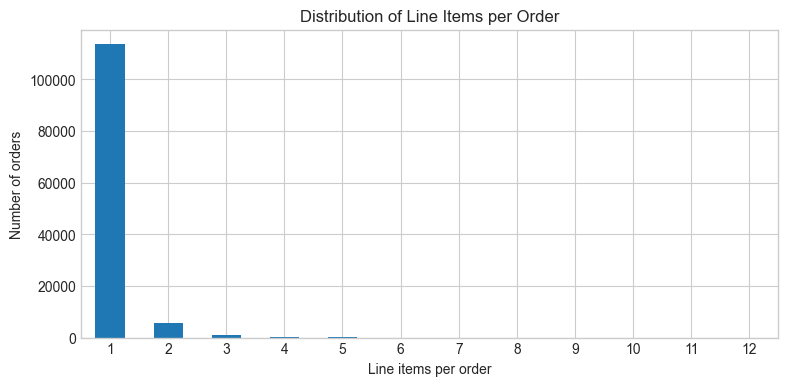

In [16]:
ax = order_line_counts.value_counts().sort_index().head(12).plot(
    kind="bar",
    figsize=(9, 4),
    title="Distribution of Line Items per Order"
)
ax.set_xlabel("Line items per order")
ax.set_ylabel("Number of orders")
plt.xticks(rotation=0)
plt.show()


## 8. Chuẩn hóa tên cột 

In [17]:
def clean_column_name(col: str) -> str:
    return (
        col.strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace(":", "")
        .replace("__", "_")
    )

df = df_raw.copy()
df.columns = [clean_column_name(c) for c in df.columns]
df.columns.tolist()


['index',
 'order_id',
 'date',
 'status',
 'fulfilment',
 'sales_channel',
 'ship_service_level',
 'style',
 'sku',
 'category',
 'size',
 'asin',
 'courier_status',
 'qty',
 'currency',
 'amount',
 'ship_city',
 'ship_state',
 'ship_postal_code',
 'ship_country',
 'promotion_ids',
 'b2b',
 'fulfilled_by',
 'unnamed_22']

## 9. Drop cột không hữu ích

In [18]:
columns_to_drop = []

if "index" in df.columns:
    columns_to_drop.append("index")

if "unnamed_22" in df.columns:
    columns_to_drop.append("unnamed_22")

columns_to_drop


['index', 'unnamed_22']

In [19]:
df = df.drop(columns=columns_to_drop)
df.head()

,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,"400,081.00",IN,NaN,False,Easy Ship
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,"560,085.00",IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,"410,210.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,"605,008.00",IN,NaN,False,Easy Ship
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,"600,073.00",IN,NaN,False,NaN


## 10. Parse ngày tháng

In [20]:
df["date"] = pd.to_datetime(df["date"], format="%m-%d-%y", errors="coerce")
print(df["date"].dtypes)
df["date"].head()


datetime64[ns]


0   2022-04-30
1   2022-04-30
2   2022-04-30
3   2022-04-30
4   2022-04-30
Name: date, dtype: datetime64[ns]

In [21]:
df["date"].isna().sum()

np.int64(0)

In [22]:
df["date"].min(), df["date"].max()

(Timestamp('2022-03-31 00:00:00'), Timestamp('2022-06-29 00:00:00'))

### Chuẩn hóa text sau khi parse date

Một số cột location có cùng giá trị nhưng khác kiểu viết hoa/thường, ví dụ `HYDERABAD` và `Hyderabad`. Nếu không chuẩn hóa, groupby theo city/state sẽ bị tách sai nhóm.

In [23]:
text_cols_to_strip = [
    "status", "fulfilment", "sales_channel", "ship_service_level",
    "category", "size", "courier_status", "currency", "ship_country",
    "ship_city", "ship_state", "fulfilled_by"
]

for col in text_cols_to_strip:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

for col in ["ship_city", "ship_state", "ship_country"]:
    if col in df.columns:
        df[col] = df[col].str.upper()

if "category" in df.columns:
    df["category"] = df["category"].str.title()

if "sales_channel" in df.columns:
    df["sales_channel"] = df["sales_channel"].str.strip()

df[["category", "ship_city", "ship_state", "sales_channel"]].head()


,category,ship_city,ship_state,sales_channel
0,Set,MUMBAI,MAHARASHTRA,Amazon.in
1,Kurta,BENGALURU,KARNATAKA,Amazon.in
2,Kurta,NAVI MUMBAI,MAHARASHTRA,Amazon.in
3,Western Dress,PUDUCHERRY,PUDUCHERRY,Amazon.in
4,Top,CHENNAI,TAMIL NADU,Amazon.in


## 11. Kiểm tra phân phối các cột categorical quan trọng

In [24]:
categorical_cols = [
    "status",
    "fulfilment",
    "sales_channel",
    "ship_service_level",
    "category",
    "size",
    "courier_status",
    "currency",
    "ship_country",
    "b2b",
    "fulfilled_by",
]

for col in categorical_cols:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False).head(20))


--- status ---
status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: Int64

--- fulfilment ---
fulfilment
Amazon      89698
Merchant    39277
Name: count, dtype: Int64

--- sales_channel ---
sales_channel
Amazon.in     128851
Non-Amazon       124
Name: count, dtype: Int64

--- ship_service_level ---
ship_service_level
Expedited    88615
Standard     40360
Name: count, dtype: Int64

--- category ---
category
Set              50284
Kurta            49877
Western Dress    15500
Top              10622
Ethnic Dress    

### Nhận xét categorical columns

- `Status` có 13 trạng thái, trong đó `Shipped`, `Shipped - Delivered to Buyer`, và `Cancelled` là nhóm quan trọng nhất.
- `Category` chỉ có 9 nhóm, rất phù hợp cho dashboard và ecommerce-specific tools.
- `Sales Channel` gần như toàn bộ là `Amazon.in`; cột này ít giá trị phân tách trong dataset hiện tại.
- `B2B` rất lệch lớp: đa số là non-B2B, nên khi so sánh cần chú ý kích thước mẫu.
- `Courier Status` và `Status` nên được phân tích cùng nhau để hiểu đơn bị hủy/giao/thất bại.

## 12. Kiểm tra các cột numeric quan trọng

In [25]:
numeric_cols = ["qty", "amount", "ship_postal_code"]

df[numeric_cols].describe()

,qty,amount,ship_postal_code
count,"128,975.00","121,180.00","128,942.00"
mean,0.90,648.56,"463,966.24"
std,0.31,281.21,"191,476.76"
min,0.00,0.00,"110,001.00"
25%,1.00,449.00,"382,421.00"
50%,1.00,605.00,"500,033.00"
75%,1.00,788.00,"600,024.00"
max,15.00,"5,584.00","989,898.00"


In [26]:
df[["qty", "amount"]].isna().sum()

qty          0
amount    7795
dtype: int64

In [27]:
df[df["amount"].isna()].head()

,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by
8,407-5443024-5233168,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,SET200,SET200-KR-NP-A-XXXL,Set,3XL,B08L91ZZXN,Cancelled,0,<NA>,NaN,HYDERABAD,TELANGANA,"500,008.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,<NA>
29,404-5933402-8801952,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,JNE2132,JNE2132-KR-398-XXXL,Kurta,3XL,B07JG3CND8,<NA>,0,<NA>,NaN,GUWAHATI,ASSAM,"781,003.00",IN,NaN,False,Easy Ship
65,171-4137548-0481151,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,JNE3373,JNE3373-KR-XXL,Kurta,XXL,B082W8RWN1,Cancelled,0,<NA>,NaN,DAHOD,GUJARAT,"389,151.00",IN,NaN,False,<NA>
84,403-9950518-0349133,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,JNE3510,JNE3510-KR-M,Kurta,M,B08WPR5MCB,Cancelled,0,<NA>,NaN,HYDERABAD,TELANGANA,"500,072.00",IN,NaN,False,<NA>
95,405-9112089-3379536,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,JNE3405,JNE3405-KR-L,Kurta,L,B081WSCKPQ,Cancelled,0,<NA>,NaN,PUNE,MAHARASHTRA,"411,046.00",IN,NaN,False,<NA>


### Đào sâu `amount` missing

`Amount` là cột quan trọng nhất cho revenue. Trước khi tính tổng doanh thu, cần biết missing amount có tập trung ở trạng thái nào không.

In [28]:
amount_missing_by_status = (
    df.assign(amount_missing=df["amount"].isna())
    .groupby("status", dropna=False)
    .agg(
        rows=("order_id", "count"),
        missing_amount=("amount_missing", "sum"),
    )
    .assign(missing_amount_percent=lambda x: (x["missing_amount"] / x["rows"] * 100).round(2))
    .sort_values("missing_amount", ascending=False)
)

amount_missing_by_status


,rows,missing_amount,missing_amount_percent
status,,,
Cancelled,18332,7566,41.27
Shipped,77804,208,0.27
Shipped - Delivered to Buyer,28769,8,0.03
Shipping,8,8,100.00
Shipped - Returned to Seller,1953,3,0.15
Pending,658,2,0.30
Pending - Waiting for Pick Up,281,0,0.00
Shipped - Damaged,1,0,0.00
Shipped - Lost in Transit,5,0,0.00


In [29]:
qty_zero_summary = {
    "qty_zero_rows": int((df["qty"] == 0).sum()),
    "qty_zero_and_amount_missing": int(((df["qty"] == 0) & df["amount"].isna()).sum()),
    "qty_zero_revenue_sum": float(df.loc[df["qty"] == 0, "amount"].sum(skipna=True)),
}

qty_zero_summary


{'qty_zero_rows': 12807,
 'qty_zero_and_amount_missing': 7671,
 'qty_zero_revenue_sum': 3190172.3}

## 13. Feature engineering

In [30]:
df["order_year"] = df["date"].dt.year
df["order_month"] = df["date"].dt.to_period("M").astype(str)
df["order_day"] = df["date"].dt.day
df["order_day_name"] = df["date"].dt.day_name()

In [31]:
df["status_clean"] = df["status"].astype(str).str.lower()

df["is_cancelled"] = df["status_clean"].str.contains("cancelled", na=False)
df["is_shipped"] = df["status_clean"].str.contains("shipped", na=False)
df["is_delivered"] = df["status_clean"].str.contains("delivered", na=False)

df["has_promotion"] = df["promotion_ids"].notna() if "promotion_ids" in df.columns else False
df["revenue"] = df["amount"]

df["amount_per_item"] = np.where(
    df["qty"] > 0,
    df["amount"] / df["qty"],
    np.nan
)

df.head()

,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,order_year,order_month,order_day,order_day_name,status_clean,is_cancelled,is_shipped,is_delivered,has_promotion,revenue,amount_per_item
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,<NA>,0,INR,647.62,MUMBAI,MAHARASHTRA,"400,081.00",IN,NaN,False,Easy Ship,2022,2022-04,30,Saturday,cancelled,True,False,False,False,647.62,NaN
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,Kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,"560,085.00",IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,2022,2022-04,30,Saturday,shipped - delivered to buyer,False,True,True,True,406.00,406.00
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,Kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,"410,210.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,<NA>,2022,2022-04,30,Saturday,shipped,False,True,False,True,329.00,329.00
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,<NA>,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,"605,008.00",IN,NaN,False,Easy Ship,2022,2022-04,30,Saturday,cancelled,True,False,False,False,753.33,NaN
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,"600,073.00",IN,NaN,False,<NA>,2022,2022-04,30,Saturday,shipped,False,True,False,False,574.00,574.00


## 14. Tổng quan sau khi clean và feature engineering

In [32]:
overview = {
    "rows": len(df),
    "columns": df.shape[1],
    "date_min": df["date"].min(),
    "date_max": df["date"].max(),
    "total_revenue": df["revenue"].sum(skipna=True),
    "total_qty": df["qty"].sum(skipna=True),
    "unique_orders": df["order_id"].nunique(),
    "cancel_rate": df["is_cancelled"].mean(),
}

overview

{'rows': 128975,
 'columns': 33,
 'date_min': Timestamp('2022-03-31 00:00:00'),
 'date_max': Timestamp('2022-06-29 00:00:00'),
 'total_revenue': np.float64(78592678.3),
 'total_qty': np.int64(116649),
 'unique_orders': 120378,
 'cancel_rate': np.float64(0.14213607288234154)}

### Nhận xét overview sau feature engineering

Dataset sau cleaning/feature engineering có khoảng 128,975 dòng và 120,378 order unique. Khoảng thời gian dữ liệu là từ 2022-03-31 đến 2022-06-29, tức chỉ khoảng 3 tháng, nên các phân tích seasonal dài hạn chưa phù hợp.

Tổng revenue tính từ `amount` là khoảng 78.6 triệu INR. Cancel rate theo line-item khoảng 14.2%, đủ lớn để cần có riêng tool phân tích cancellation.

## 15. Data quality summary

In [33]:
quality_summary = {
    "duplicate_rows": int(df.duplicated().sum()),
    "missing_amount": int(df["amount"].isna().sum()),
    "missing_currency": int(df["currency"].isna().sum()),
    "missing_ship_city": int(df["ship_city"].isna().sum()),
    "missing_ship_state": int(df["ship_state"].isna().sum()),
    "missing_ship_country": int(df["ship_country"].isna().sum()),
}

quality_summary

{'duplicate_rows': 6,
 'missing_amount': 7795,
 'missing_currency': 7795,
 'missing_ship_city': 33,
 'missing_ship_state': 33,
 'missing_ship_country': 33}

### Nhận xét data quality summary

Sau khi drop các cột không hữu ích, xuất hiện một số duplicate rows vì cột `index` ban đầu từng làm mỗi dòng khác nhau. Cần kiểm tra các duplicate này trước khi quyết định drop trong production pipeline.

`Amount` và `currency` missing 7,795 dòng. Đây là data quality warning quan trọng vì ảnh hưởng trực tiếp đến revenue analysis.

In [34]:
df[df.duplicated(keep=False)].sort_values(["order_id", "sku"]).head(20)


,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,order_year,order_month,order_day,order_day_name,status_clean,is_cancelled,is_shipped,is_delivered,has_promotion,revenue,amount_per_item
85790,171-3249942-2207542,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,SET323,SET323-KR-NP-XL,Set,XL,B09NDKKM7P,Shipped,1,INR,939.00,PUNE,MAHARASHTRA,"411,057.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,<NA>,2022,2022-05,3,Tuesday,shipped,False,True,False,True,939.00,939.00
85791,171-3249942-2207542,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,SET323,SET323-KR-NP-XL,Set,XL,B09NDKKM7P,Shipped,1,INR,939.00,PUNE,MAHARASHTRA,"411,057.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,<NA>,2022,2022-05,3,Tuesday,shipped,False,True,False,True,939.00,939.00
79844,171-9628368-5329958,2022-05-07,Cancelled,Amazon,Amazon.in,Expedited,J0329,J0329-KR-L,Kurta,L,B09KXRB7JV,Cancelled,0,<NA>,NaN,ERNAKULAM,KERALA,"682,017.00",IN,NaN,False,<NA>,2022,2022-05,7,Saturday,cancelled,True,False,False,False,NaN,NaN
79845,171-9628368-5329958,2022-05-07,Cancelled,Amazon,Amazon.in,Expedited,J0329,J0329-KR-L,Kurta,L,B09KXRB7JV,Cancelled,0,<NA>,NaN,ERNAKULAM,KERALA,"682,017.00",IN,NaN,False,<NA>,2022,2022-05,7,Saturday,cancelled,True,False,False,False,NaN,NaN
86418,405-8669298-3850736,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,MEN5025,MEN5025-KR-XXXL,Kurta,3XL,B08YYQS8FH,Shipped,1,INR,533.00,GHAZIABAD,UTTAR PRADESH,"201,010.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,<NA>,2022,2022-05,3,Tuesday,shipped,False,True,False,True,533.00,533.00
86419,405-8669298-3850736,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,MEN5025,MEN5025-KR-XXXL,Kurta,3XL,B08YYQS8FH,Shipped,1,INR,533.00,GHAZIABAD,UTTAR PRADESH,"201,010.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,<NA>,2022,2022-05,3,Tuesday,shipped,False,True,False,True,533.00,533.00
30660,406-0372545-6086735,2022-04-12,Cancelled,Amazon,Amazon.in,Expedited,SET197,SET197-KR-NP-L,Set,L,B08B3YPD63,Cancelled,0,<NA>,NaN,SILIGURI,WEST BENGAL,"734,008.00",IN,NaN,False,<NA>,2022,2022-04,12,Tuesday,cancelled,True,False,False,False,NaN,NaN
30661,406-0372545-6086735,2022-04-12,Cancelled,Amazon,Amazon.in,Expedited,SET197,SET197-KR-NP-L,Set,L,B08B3YPD63,Cancelled,0,<NA>,NaN,SILIGURI,WEST BENGAL,"734,008.00",IN,NaN,False,<NA>,2022,2022-04,12,Tuesday,cancelled,True,False,False,False,NaN,NaN
98954,407-4853873-4978725,2022-06-22,Shipped,Amazon,Amazon.in,Expedited,J0230,J0230-SKD-M,Set,M,B08XNJG8B1,Shipped,1,INR,"1,163.00",ZIRAKPUR,PUNJAB,"140,603.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,<NA>,2022,2022-06,22,Wednesday,shipped,False,True,False,True,"1,163.00","1,163.00"
98955,407-4853873-4978725,2022-06-22,Shipped,Amazon,Amazon.in,Expedited,J0230,J0230-SKD-M,Set,M,B08XNJG8B1,Shipped,1,INR,"1,163.00",ZIRAKPUR,PUNJAB,"140,603.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,<NA>,2022,2022-06,22,Wednesday,shipped,False,True,False,True,"1,163.00","1,163.00"


## 16. Phân tích doanh thu theo thời gian

In [35]:
revenue_by_month = (
    df.groupby("order_month", dropna=False)["revenue"]
    .sum()
    .reset_index()
    .sort_values("order_month")
)

revenue_by_month

,order_month,revenue
0,2022-03,"101,683.85"
1,2022-04,"28,838,708.32"
2,2022-05,"26,226,476.75"
3,2022-06,"23,425,809.38"


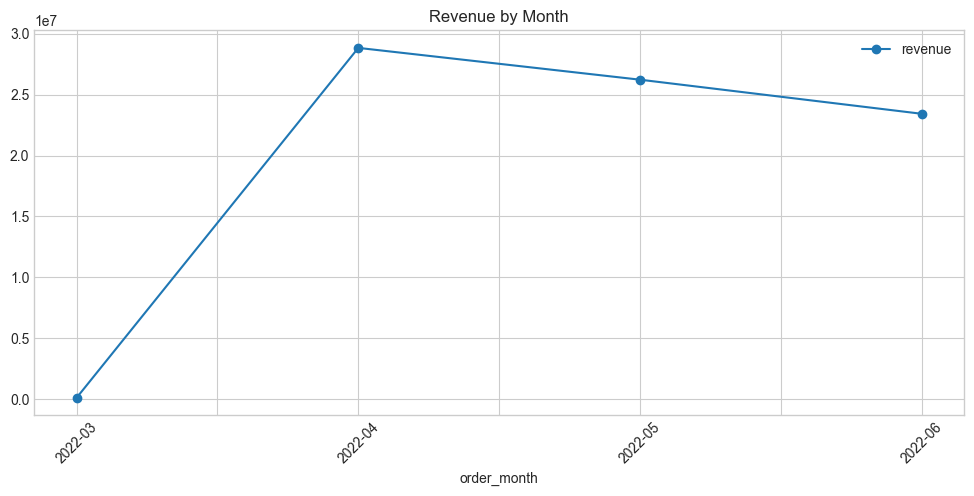

In [36]:
revenue_by_month.plot(
    x="order_month",
    y="revenue",
    kind="line",
    marker="o",
    figsize=(12, 5),
    title="Revenue by Month"
)

plt.xticks(rotation=45)
plt.show()

### Đào sâu theo ngày

Dữ liệu chỉ kéo dài khoảng 3 tháng, vì vậy phân tích theo ngày hữu ích hơn phân tích theo năm/quý. Ta xem thêm revenue, số order, và cancel rate theo từng ngày.

In [37]:
daily_summary = (
    df.groupby("date")
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
        cancel_rate=("is_cancelled", "mean"),
    )
    .reset_index()
    .sort_values("date")
)

daily_summary.head()


,date,revenue,orders,cancel_rate
0,2022-03-31,"101,683.85",158,0.11
1,2022-04-01,"865,478.60",1363,0.16
2,2022-04-02,"913,101.53",1452,0.16
3,2022-04-03,"1,011,763.38",1565,0.14
4,2022-04-04,"882,059.17",1376,0.14


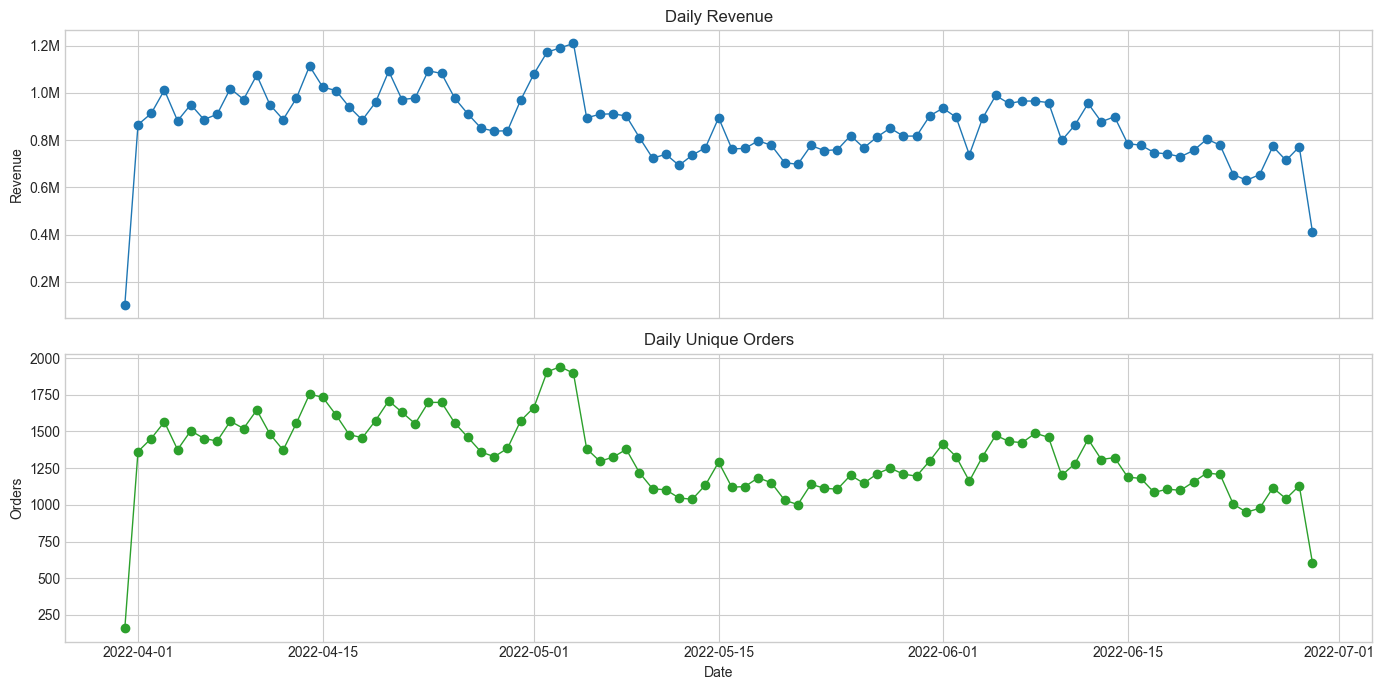

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(daily_summary["date"], daily_summary["revenue"], marker="o", linewidth=1)
axes[0].set_title("Daily Revenue")
axes[0].set_ylabel("Revenue")
format_inr_axis(axes[0])

axes[1].plot(daily_summary["date"], daily_summary["orders"], marker="o", color="tab:green", linewidth=1)
axes[1].set_title("Daily Unique Orders")
axes[1].set_ylabel("Orders")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()


In [39]:
top_revenue_days = daily_summary.sort_values("revenue", ascending=False).head(10)
top_revenue_days


,date,revenue,orders,cancel_rate
34,2022-05-04,"1,209,364.17",1896,0.15
33,2022-05-03,"1,190,672.59",1941,0.16
32,2022-05-02,"1,172,327.06",1906,0.15
14,2022-04-14,"1,113,487.56",1754,0.14
23,2022-04-23,"1,093,536.62",1698,0.14
20,2022-04-20,"1,091,926.41",1709,0.12
24,2022-04-24,"1,082,483.95",1698,0.14
31,2022-05-01,"1,079,957.52",1663,0.13
10,2022-04-10,"1,075,234.03",1646,0.12
15,2022-04-15,"1,024,542.13",1733,0.17


## 17. Phân tích theo category

In [40]:
category_summary = (
    df.groupby("category", dropna=False)
    .agg(
        revenue=("revenue", "sum"),
        qty=("qty", "sum"),
        orders=("order_id", "nunique"),
        cancel_rate=("is_cancelled", "mean"),
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

category_summary

,category,revenue,qty,orders,cancel_rate
6,Set,"39,204,124.03",45289,47845,0.15
4,Kurta,"21,299,546.70",45045,46561,0.15
8,Western Dress,"11,216,072.69",13943,14994,0.14
7,Top,"5,347,792.30",9903,10155,0.12
3,Ethnic Dress,"791,217.66",1053,1148,0.13
0,Blouse,"458,408.18",863,897,0.13
1,Bottom,"150,667.98",398,410,0.14
5,Saree,"123,933.76",152,144,0.13
2,Dupatta,915.00,3,2,0.00


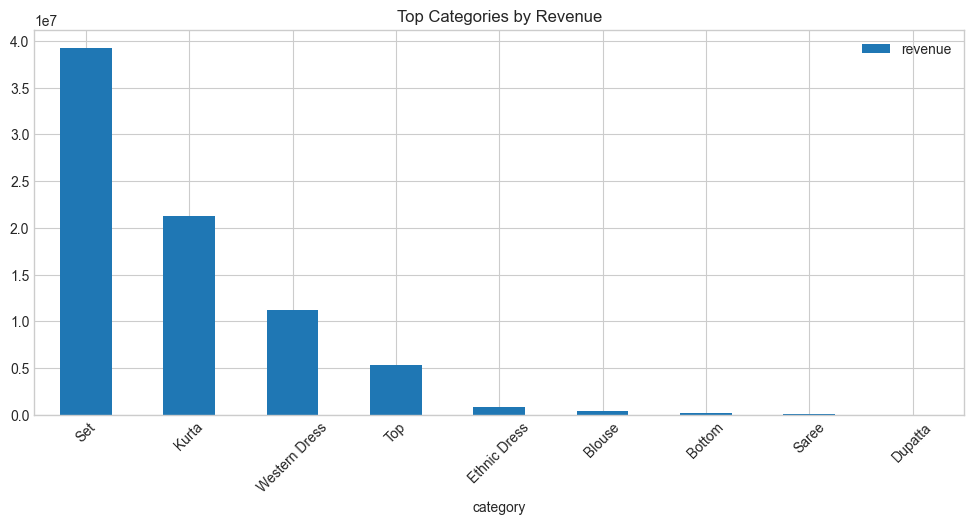

In [41]:
category_summary.head(10).plot(
    x="category",
    y="revenue",
    kind="bar",
    figsize=(12, 5),
    title="Top Categories by Revenue"
)

plt.xticks(rotation=45)
plt.show()

### Đào sâu category: revenue và cancellation

Category không chỉ cần xếp theo revenue. Với ecommerce agent, ta nên so sánh thêm cancel rate để tìm nhóm vừa lớn vừa rủi ro.

In [42]:
category_summary = category_summary.assign(
    revenue_share=(category_summary["revenue"] / category_summary["revenue"].sum() * 100).round(2),
    cancel_rate_percent=(category_summary["cancel_rate"] * 100).round(2),
)

category_summary


,category,revenue,qty,orders,cancel_rate,revenue_share,cancel_rate_percent
6,Set,"39,204,124.03",45289,47845,0.15,49.88,14.59
4,Kurta,"21,299,546.70",45045,46561,0.15,27.10,14.55
8,Western Dress,"11,216,072.69",13943,14994,0.14,14.27,13.69
7,Top,"5,347,792.30",9903,10155,0.12,6.80,12.01
3,Ethnic Dress,"791,217.66",1053,1148,0.13,1.01,12.51
0,Blouse,"458,408.18",863,897,0.13,0.58,12.53
1,Bottom,"150,667.98",398,410,0.14,0.19,13.64
5,Saree,"123,933.76",152,144,0.13,0.16,12.80
2,Dupatta,915.00,3,2,0.00,0.00,0.00


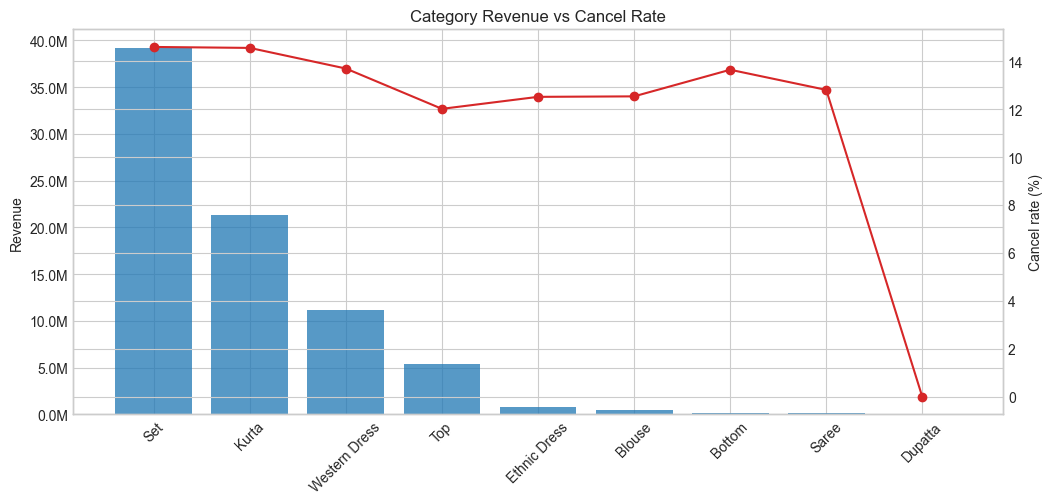

In [43]:
fig, ax1 = plt.subplots(figsize=(12, 5))
plot_df = category_summary.sort_values("revenue", ascending=False)

ax1.bar(plot_df["category"], plot_df["revenue"], color="tab:blue", alpha=0.75)
ax1.set_ylabel("Revenue")
format_inr_axis(ax1)
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(plot_df["category"], plot_df["cancel_rate_percent"], color="tab:red", marker="o")
ax2.set_ylabel("Cancel rate (%)")

plt.title("Category Revenue vs Cancel Rate")
plt.show()


## 18. Phân tích theo khu vực

In [44]:
state_summary = (
    df.groupby("ship_state", dropna=False)
    .agg(
        revenue=("revenue", "sum"),
        qty=("qty", "sum"),
        orders=("order_id", "nunique"),
        cancel_rate=("is_cancelled", "mean"),
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

state_summary.head(20)

,ship_state,revenue,qty,orders,cancel_rate
22,MAHARASHTRA,"13,335,534.14",20328,20780,0.13
17,KARNATAKA,"10,481,114.37",15901,16182,0.13
42,TELANGANA,"6,916,615.65",10253,10405,0.14
44,UTTAR PRADESH,"6,816,642.08",9499,10062,0.15
41,TAMIL NADU,"6,515,650.11",10412,10519,0.14
10,DELHI,"4,346,412.46",6326,6533,0.13
18,KERALA,"3,830,227.58",5813,6105,0.18
46,WEST BENGAL,"3,507,880.44",5318,5653,0.15
1,ANDHRA PRADESH,"3,219,831.72",4819,4979,0.16
13,HARYANA,"2,882,092.99",4066,4142,0.13


In [45]:
city_summary = (
    df.groupby("ship_city", dropna=False)
    .agg(
        revenue=("revenue", "sum"),
        qty=("qty", "sum"),
        orders=("order_id", "nunique"),
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

city_summary.head(20)

,ship_city,revenue,qty,orders
810,BENGALURU,"7,257,748.80",11038,11096
2540,HYDERABAD,"5,599,822.35",8284,8369
4331,MUMBAI,"4,293,210.16",6576,6572
4753,NEW DELHI,"3,952,690.20",5754,5948
1314,CHENNAI,"3,606,917.94",5756,5726
5488,PUNE,"2,794,975.79",4237,4317
3423,KOLKATA,"1,682,046.99",2586,2687
2337,GURUGRAM,"1,280,854.78",1815,1855
6568,THANE,"1,111,506.35",1703,1770
3785,LUCKNOW,"1,049,983.10",1441,1556


### Location charts

Sau khi chuẩn hóa city/state về uppercase, các thành phố như `HYDERABAD` và `Hyderabad` được gom đúng vào một nhóm. Đây là bước quan trọng trước khi viết production cleaner.

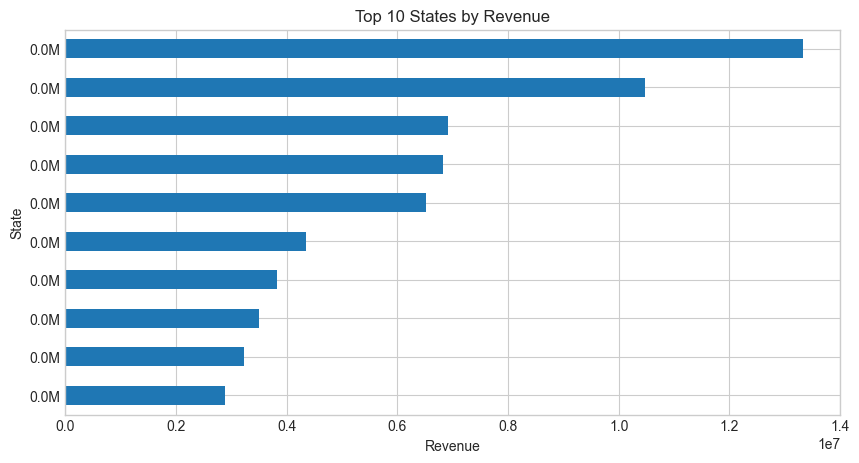

In [46]:
top_states = state_summary.head(10).sort_values("revenue")
ax = top_states.plot(
    x="ship_state",
    y="revenue",
    kind="barh",
    figsize=(10, 5),
    title="Top 10 States by Revenue",
    legend=False,
)
ax.set_xlabel("Revenue")
ax.set_ylabel("State")
format_inr_axis(ax)
plt.show()


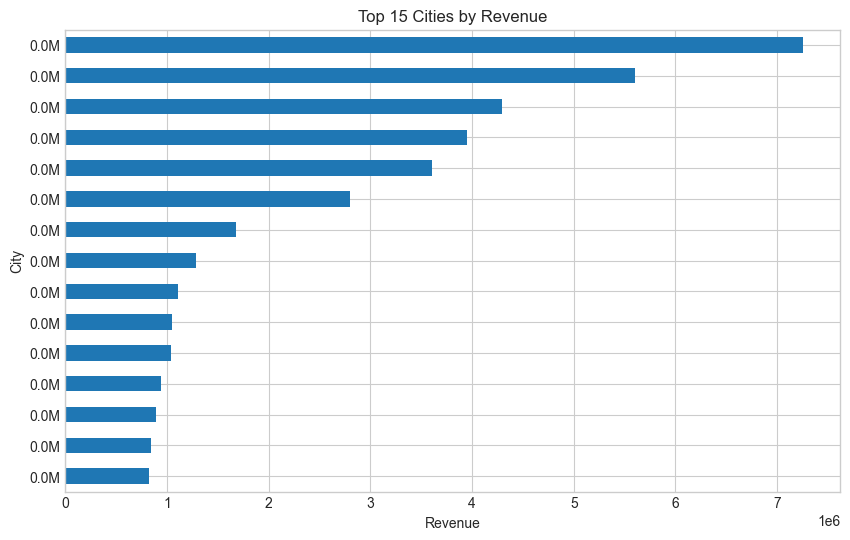

In [47]:
top_cities = city_summary.head(15).sort_values("revenue")
ax = top_cities.plot(
    x="ship_city",
    y="revenue",
    kind="barh",
    figsize=(10, 6),
    title="Top 15 Cities by Revenue",
    legend=False,
)
ax.set_xlabel("Revenue")
ax.set_ylabel("City")
format_inr_axis(ax)
plt.show()


In [48]:
high_volume_state_risk = (
    state_summary[state_summary["orders"] >= 1000]
    .sort_values("cancel_rate", ascending=False)
    .head(10)
)

high_volume_state_risk


,ship_state,revenue,qty,orders,cancel_rate
18,KERALA,"3,830,227.58",5813,6105,0.18
1,ANDHRA PRADESH,"3,219,831.72",4819,4979,0.16
29,ODISHA,"1,384,635.39",1908,2021,0.16
6,BIHAR,"1,415,613.32",1875,2017,0.16
16,JHARKHAND,"919,088.21",1284,1382,0.16
44,UTTAR PRADESH,"6,816,642.08",9499,10062,0.15
45,UTTARAKHAND,"974,143.55",1385,1480,0.15
21,MADHYA PRADESH,"1,592,382.98",2260,2375,0.15
5,ASSAM,"1,018,136.20",1483,1601,0.15
46,WEST BENGAL,"3,507,880.44",5318,5653,0.15


## 19. Phân tích trạng thái đơn hàng

In [49]:
status_summary = (
    df.groupby("status", dropna=False)
    .agg(
        rows=("order_id", "count"),
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum"),
        qty=("qty", "sum"),
    )
    .reset_index()
    .sort_values("rows", ascending=False)
)

status_summary

,status,rows,orders,revenue,qty
3,Shipped,77804,72826,"50,324,255.00",78009
5,Shipped - Delivered to Buyer,28769,26566,"18,650,815.00",28886
0,Cancelled,18332,17185,"6,919,284.30",5657
10,Shipped - Returned to Seller,1953,1851,"1,269,644.00",1970
8,Shipped - Picked Up,973,918,"661,252.00",977
1,Pending,658,584,"430,271.00",657
2,Pending - Waiting for Pick Up,281,262,"192,138.00",283
11,Shipped - Returning to Seller,145,130,"107,620.00",150
7,Shipped - Out for Delivery,35,32,"26,971.00",35
9,Shipped - Rejected by Buyer,11,11,"7,295.00",11


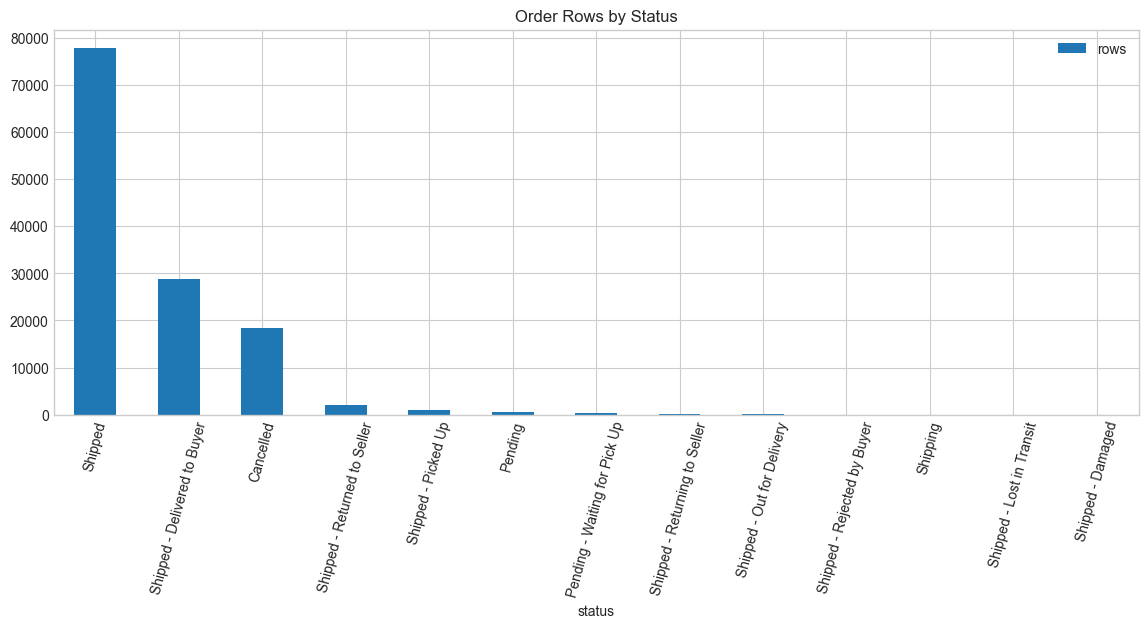

In [50]:
status_summary.plot(
    x="status",
    y="rows",
    kind="bar",
    figsize=(14, 5),
    title="Order Rows by Status"
)

plt.xticks(rotation=75)
plt.show()

### Nhận xét trạng thái đơn hàng

`Shipped` và `Shipped - Delivered to Buyer` chiếm phần lớn dataset, nhưng `Cancelled` vẫn là trạng thái lớn thứ ba. Vì `Cancelled` ảnh hưởng trực tiếp đến revenue và operations, cancellation analysis nên là một ecommerce tool riêng.

In [51]:
status_summary = status_summary.assign(
    row_percent=(status_summary["rows"] / status_summary["rows"].sum() * 100).round(2)
)

status_summary[["status", "rows", "row_percent", "revenue", "qty"]]


,status,rows,row_percent,revenue,qty
3,Shipped,77804,60.32,"50,324,255.00",78009
5,Shipped - Delivered to Buyer,28769,22.31,"18,650,815.00",28886
0,Cancelled,18332,14.21,"6,919,284.30",5657
10,Shipped - Returned to Seller,1953,1.51,"1,269,644.00",1970
8,Shipped - Picked Up,973,0.75,"661,252.00",977
1,Pending,658,0.51,"430,271.00",657
2,Pending - Waiting for Pick Up,281,0.22,"192,138.00",283
11,Shipped - Returning to Seller,145,0.11,"107,620.00",150
7,Shipped - Out for Delivery,35,0.03,"26,971.00",35
9,Shipped - Rejected by Buyer,11,0.01,"7,295.00",11


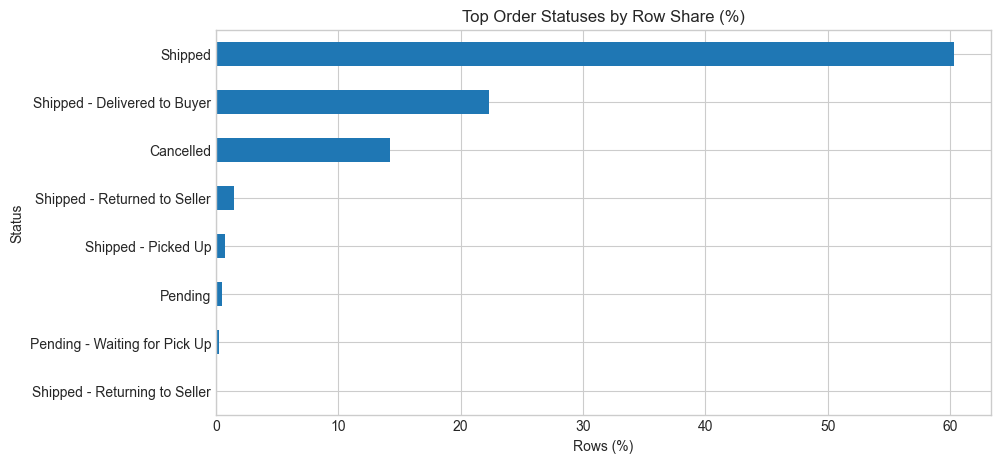

In [52]:
plot_df = status_summary.sort_values("row_percent").tail(8)
ax = plot_df.plot(
    x="status",
    y="row_percent",
    kind="barh",
    figsize=(10, 5),
    title="Top Order Statuses by Row Share (%)",
    legend=False,
)
ax.set_xlabel("Rows (%)")
ax.set_ylabel("Status")
plt.show()


## 20. Phân tích fulfillment và courier

In [53]:
fulfilment_summary = (
    df.groupby("fulfilment", dropna=False)
    .agg(
        revenue=("revenue", "sum"),
        qty=("qty", "sum"),
        orders=("order_id", "nunique"),
        cancel_rate=("is_cancelled", "mean"),
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

fulfilment_summary

,fulfilment,revenue,qty,orders,cancel_rate
0,Amazon,"54,322,151.00",84087,84002,0.13
1,Merchant,"24,270,527.30",32562,36376,0.17


In [54]:
courier_summary = (
    df.groupby("courier_status", dropna=False)
    .agg(
        rows=("order_id", "count"),
        revenue=("revenue", "sum"),
        qty=("qty", "sum"),
    )
    .reset_index()
    .sort_values("rows", ascending=False)
)

courier_summary

,courier_status,rows,revenue,qty
1,Shipped,109487,"71,058,664.00",109896
3,<NA>,6872,"3,190,172.30",0
2,Unshipped,6681,"4,343,842.00",6753
0,Cancelled,5935,0.00,0


### Fulfillment and courier charts

Fulfillment type cần được xem cùng cancel rate. Nếu một fulfillment mode có cancel rate cao hơn, đây là insight vận hành đáng đưa vào report.

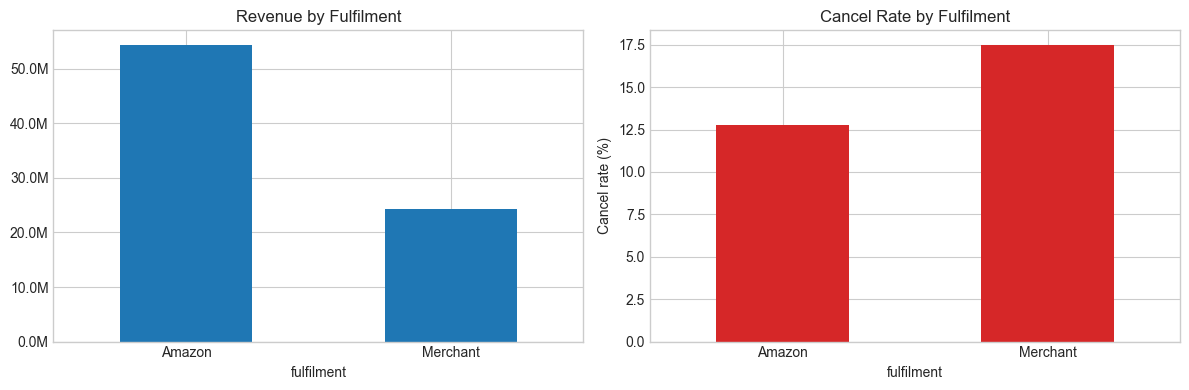

In [55]:
fulfilment_plot = fulfilment_summary.assign(cancel_rate_percent=fulfilment_summary["cancel_rate"] * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fulfilment_plot.plot(x="fulfilment", y="revenue", kind="bar", ax=axes[0], legend=False, title="Revenue by Fulfilment")
format_inr_axis(axes[0])
axes[0].tick_params(axis="x", rotation=0)

fulfilment_plot.plot(x="fulfilment", y="cancel_rate_percent", kind="bar", ax=axes[1], legend=False, color="tab:red", title="Cancel Rate by Fulfilment")
axes[1].set_ylabel("Cancel rate (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


In [56]:
courier_plot = courier_summary.copy()
courier_plot["revenue_share"] = courier_plot["revenue"] / courier_plot["revenue"].sum() * 100
courier_plot


,courier_status,rows,revenue,qty,revenue_share
1,Shipped,109487,"71,058,664.00",109896,90.41
3,<NA>,6872,"3,190,172.30",0,4.06
2,Unshipped,6681,"4,343,842.00",6753,5.53
0,Cancelled,5935,0.00,0,0.00


## 21. Phân tích B2B vs non-B2B

In [57]:
b2b_summary = (
    df.groupby("b2b", dropna=False)
    .agg(
        revenue=("revenue", "sum"),
        qty=("qty", "sum"),
        orders=("order_id", "nunique"),
        avg_order_value=("revenue", "mean"),
        cancel_rate=("is_cancelled", "mean"),
    )
    .reset_index()
)

b2b_summary

,b2b,revenue,qty,orders,avg_order_value,cancel_rate
0,False,"78,001,457.51",115809,119584,648.19,0.14
1,True,"591,220.79",840,794,701.33,0.08


### Nhận xét B2B vs non-B2B

B2B chỉ có số dòng rất nhỏ so với non-B2B, nên không nên kết luận quá mạnh chỉ từ trung bình. Tuy vậy, đây vẫn là segment đáng giữ vì có thể phục vụ câu hỏi phân tích theo customer type.

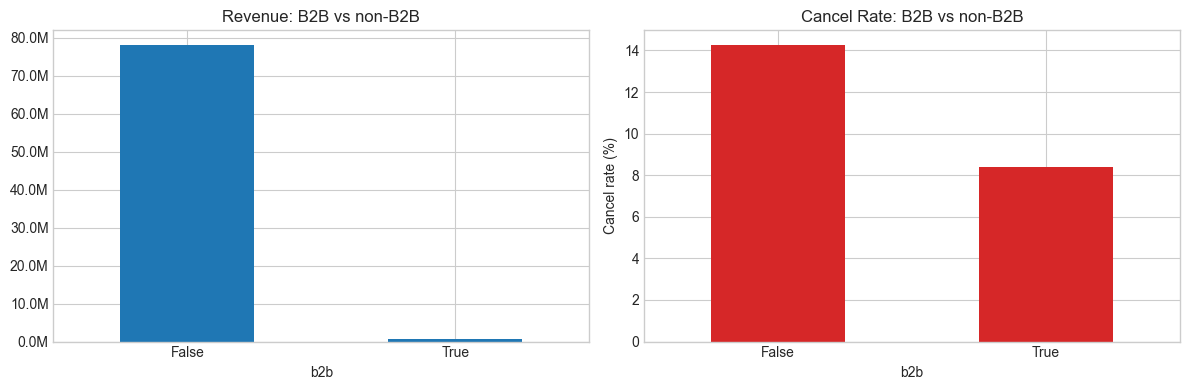

In [58]:
b2b_plot = b2b_summary.assign(cancel_rate_percent=b2b_summary["cancel_rate"] * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
b2b_plot.plot(x="b2b", y="revenue", kind="bar", ax=axes[0], legend=False, title="Revenue: B2B vs non-B2B")
format_inr_axis(axes[0])
axes[0].tick_params(axis="x", rotation=0)

b2b_plot.plot(x="b2b", y="cancel_rate_percent", kind="bar", ax=axes[1], legend=False, color="tab:red", title="Cancel Rate: B2B vs non-B2B")
axes[1].set_ylabel("Cancel rate (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## 22. Phân tích promotion

In [59]:
promotion_summary = (
    df.groupby("has_promotion", dropna=False)
    .agg(
        revenue=("revenue", "sum"),
        qty=("qty", "sum"),
        orders=("order_id", "nunique"),
        avg_amount=("revenue", "mean"),
        cancel_rate=("is_cancelled", "mean"),
    )
    .reset_index()
)

promotion_summary

,has_promotion,revenue,qty,orders,avg_amount,cancel_rate
0,False,"25,004,243.30",36798,46937,599.65,0.37
1,True,"53,588,435.00",79851,73464,674.22,0.00


### Nhận xét promotion

`has_promotion = False` có cancel rate cao bất thường. Điều này có thể do nhiều đơn cancelled không có `promotion_ids`, không nhất thiết chứng minh promotion làm giảm cancellation. Đây là ví dụ tốt để agent cần nói theo kiểu cẩn trọng: correlation/association, không kết luận causal.

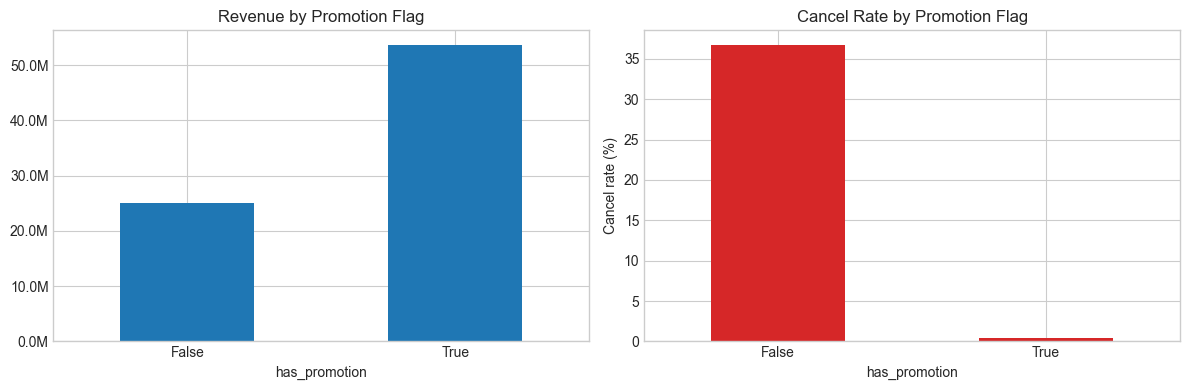

In [60]:
promotion_plot = promotion_summary.assign(cancel_rate_percent=promotion_summary["cancel_rate"] * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
promotion_plot.plot(x="has_promotion", y="revenue", kind="bar", ax=axes[0], legend=False, title="Revenue by Promotion Flag")
format_inr_axis(axes[0])
axes[0].tick_params(axis="x", rotation=0)

promotion_plot.plot(x="has_promotion", y="cancel_rate_percent", kind="bar", ax=axes[1], legend=False, color="tab:red", title="Cancel Rate by Promotion Flag")
axes[1].set_ylabel("Cancel rate (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## 23. Phân tích sản phẩm và size

Ngoài category, ecommerce dataset cần phân tích thêm SKU/ASIN/size vì đây là cấp độ gần với quyết định inventory và merchandising hơn.

In [61]:
sku_summary = (
    df.groupby(["sku", "category"], dropna=False)
    .agg(
        revenue=("revenue", "sum"),
        qty=("qty", "sum"),
        orders=("order_id", "nunique"),
        cancel_rate=("is_cancelled", "mean"),
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

sku_summary.head(15)


,sku,category,revenue,qty,orders,cancel_rate
1346,J0230-SKD-M,Set,"527,699.20",468,506,0.14
4548,JNE3797-KR-L,Western Dress,"524,581.77",661,773,0.16
1347,J0230-SKD-S,Set,"479,937.14",421,452,0.12
4549,JNE3797-KR-M,Western Dress,"454,290.16",561,657,0.16
4550,JNE3797-KR-S,Western Dress,"407,302.57",503,587,0.17
4551,JNE3797-KR-XL,Western Dress,"332,155.24",415,474,0.15
1345,J0230-SKD-L,Set,"305,616.95",272,297,0.15
4552,JNE3797-KR-XS,Western Dress,"303,616.70",386,431,0.15
6305,SET268-KR-NP-XL,Set,"284,058.96",373,386,0.11
4554,JNE3797-KR-XXXL,Western Dress,"276,375.80",353,386,0.12


In [62]:
size_summary = (
    df.groupby("size", dropna=False)
    .agg(
        revenue=("revenue", "sum"),
        qty=("qty", "sum"),
        orders=("order_id", "nunique"),
        cancel_rate=("is_cancelled", "mean"),
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

size_summary


,size,revenue,qty,orders,cancel_rate
6,M,"13,906,754.37",20447,21722,0.15
5,L,"13,234,886.19",20000,21058,0.14
8,XL,"12,464,965.86",18923,19896,0.14
10,XXL,"10,636,288.45",16516,17164,0.13
7,S,"10,629,210.18",15331,16336,0.15
0,3XL,"9,157,147.68",13524,13755,0.13
9,XS,"7,022,375.20",9943,10533,0.17
3,6XL,"576,249.33",688,681,0.10
2,5XL,"425,156.63",513,526,0.10
1,4XL,"334,451.64",398,394,0.11


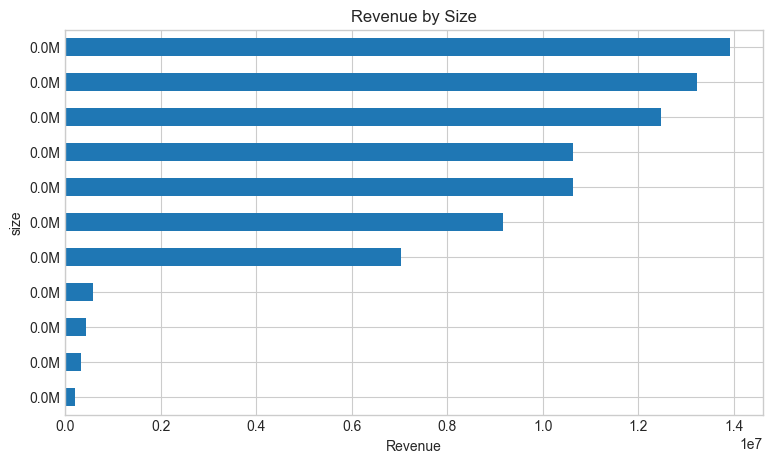

In [63]:
ax = size_summary.sort_values("revenue").plot(
    x="size",
    y="revenue",
    kind="barh",
    figsize=(9, 5),
    title="Revenue by Size",
    legend=False,
)
ax.set_xlabel("Revenue")
format_inr_axis(ax)
plt.show()


## 24. Outlier check đơn giản

In [64]:
df[["qty", "amount", "amount_per_item"]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

,qty,amount,amount_per_item
count,"128,975.00","121,180.00","116,044.00"
mean,0.90,648.56,647.52
std,0.31,281.21,278.52
min,0.00,0.00,0.00
1%,0.00,0.00,0.00
5%,0.00,301.00,301.00
50%,1.00,605.00,600.50
95%,1.00,"1,176.00","1,176.00"
99%,1.00,"1,442.00","1,442.00"
max,15.00,"5,584.00","2,598.00"


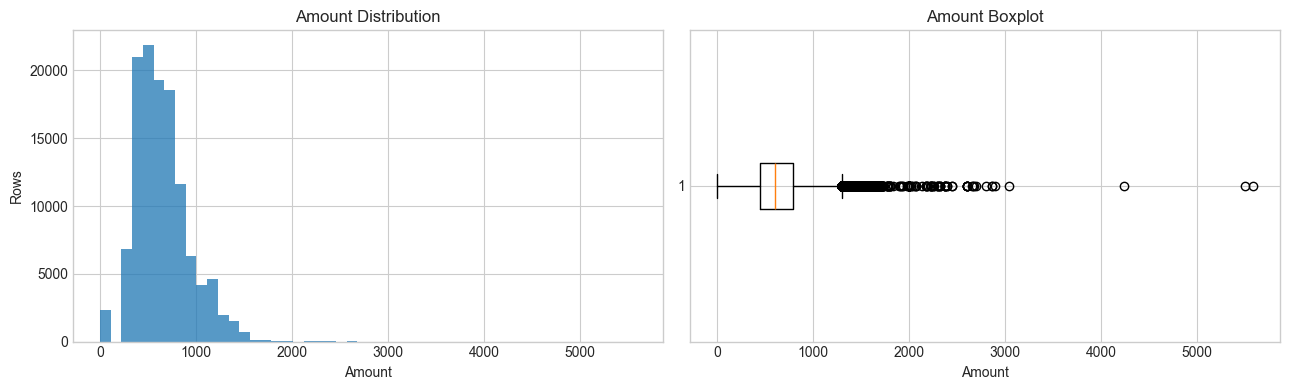

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

valid_amount = df["amount"].dropna()
axes[0].hist(valid_amount, bins=50, color="tab:blue", alpha=0.75)
axes[0].set_title("Amount Distribution")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Rows")

axes[1].boxplot(valid_amount, vert=False)
axes[1].set_title("Amount Boxplot")
axes[1].set_xlabel("Amount")

plt.tight_layout()
plt.show()


### Nhận xét outlier

`Amount` có phân phối lệch phải: đa số đơn nằm quanh vài trăm INR, nhưng có một số dòng trên 2,000-5,000 INR. Các dòng amount cao không nhất thiết là lỗi, vì có thể là đơn nhiều item hoặc sản phẩm giá cao; cần giữ lại và chỉ flag là outlier để phân tích.

In [66]:
df.nlargest(20, "amount")[[
    "order_id",
    "date",
    "status",
    "category",
    "qty",
    "amount",
    "ship_city",
    "ship_state"
]]

,order_id,date,status,category,qty,amount,ship_city,ship_state
42039,402-5239558-4281957,2022-04-05,Shipped,Set,8,"5,584.00",GUNTUR,ANDHRA PRADESH
11160,403-4106553-1691525,2022-04-23,Shipped - Delivered to Buyer,Set,5,"5,495.00",JALANDHAR,PUNJAB
24494,407-3483041-9133135,2022-04-16,Cancelled,Set,0,"4,235.72",JAIPUR,RAJASTHAN
89150,406-7195963-2374765,2022-05-02,Shipped,Set,4,"3,036.00",LUCKNOW,UTTAR PRADESH
121225,404-4712917-7300332,2022-06-06,Shipped,Set,2,"2,894.00",MUMBAI,MAHARASHTRA
28814,408-9885439-6698733,2022-04-13,Shipped,Set,2,"2,864.00",BENGALURU,KARNATAKA
39944,408-3363121-6123562,2022-04-06,Shipped - Delivered to Buyer,Western Dress,4,"2,860.00",KANPUR,UTTAR PRADESH
79899,405-6877720-7865168,2022-05-07,Shipped - Returned to Seller,Kurta,4,"2,796.00",MAHENDRAGARH,HARYANA
63974,408-9361250-7029128,2022-05-19,Shipped,Set,2,"2,698.00",KOLKATA,WEST BENGAL
75760,402-9141667-1791537,2022-05-10,Cancelled,Set,2,"2,676.00",CHENNAI,TAMIL NADU


## 25. Correlation cơ bản

In [67]:
corr_cols = ["qty", "amount", "amount_per_item"]

df[corr_cols].corr()

,qty,amount,amount_per_item
qty,1.00,0.07,-0.01
amount,0.07,1.00,0.99
amount_per_item,-0.01,0.99,1.00


## 26. Các câu hỏi business mà agent nên trả lời được

Sau EDA, agent nên trả lời được các câu hỏi theo nhiều cấp độ:

### Overview

- Dataset có bao nhiêu dòng, bao nhiêu order unique?
- Khoảng thời gian dữ liệu là từ ngày nào đến ngày nào?
- Tổng revenue, tổng quantity, cancel rate là bao nhiêu?

### Revenue analysis

- Revenue theo ngày/tháng thay đổi như thế nào?
- Ngày nào có revenue cao nhất?
- Category nào đóng góp revenue lớn nhất?
- State/city nào có revenue cao nhất?

### Operation analysis

- Tỷ lệ đơn hủy là bao nhiêu?
- Category/state/fulfilment nào có cancel rate cao?
- Courier status phân bổ như thế nào?
- Merchant fulfilment có khác Amazon fulfilment không?

### Product analysis

- SKU nào tạo revenue cao nhất?
- Size nào bán tốt nhất?
- Category nào có avg amount cao?

### Segment analysis

- B2B và non-B2B khác nhau thế nào?
- Đơn có promotion và không promotion khác nhau thế nào?

### Data quality

- Cột nào missing nhiều nhất?
- `amount` missing có tập trung ở cancelled orders không?
- Có duplicate order không, và duplicate đó có phải multi-line order không?

## 27. Recommended charts

Các chart nên đưa vào app sau này:

- Line chart: daily revenue.
- Line chart: daily unique orders.
- Bar chart: revenue by month.
- Bar chart: revenue by category.
- Combo chart: category revenue vs cancel rate.
- Bar chart: top states by revenue.
- Bar chart: top cities by revenue.
- Bar chart: order status distribution.
- Bar chart: cancel rate by fulfilment.
- Bar chart: B2B vs non-B2B revenue/cancel rate.
- Bar chart: promotion vs no promotion revenue/cancel rate.
- Bar chart: revenue by size.
- Histogram: amount distribution.
- Boxplot: amount outlier check.

Các chart quan trọng nhất cho MVP:

1. Revenue by month/day.
2. Revenue by category.
3. Top states/cities by revenue.
4. Order status distribution.
5. Cancellation summary.

## 28. Recommended reusable tools

Các logic nên chuyển từ notebook vào `app/tools/ecommerce_tools.py`:

### Overview tools

- `get_sales_overview(df)`
- `get_data_quality_summary(df)`

### Time tools

- `revenue_by_day(df)`
- `revenue_by_month(df)`
- `top_revenue_days(df, n=10)`

### Category/product tools

- `revenue_by_category(df)`
- `category_cancellation_summary(df)`
- `top_skus_by_revenue(df, n=10)`
- `revenue_by_size(df)`

### Location tools

- `top_states_by_revenue(df, n=10)`
- `top_cities_by_revenue(df, n=10)`
- `state_cancellation_summary(df, min_orders=1000)`

### Operation tools

- `status_summary(df)`
- `cancellation_summary(df)`
- `fulfilment_summary(df)`
- `courier_summary(df)`

### Segment tools

- `b2b_summary(df)`
- `promotion_summary(df)`

Tất cả tool nên trả về `dict` hoặc list JSON-serializable để FastAPI và LLM tool calling dùng được.

## 29. Data quality warnings

Các warning quan trọng phát hiện từ notebook:

- `fulfilled_by` missing rất nhiều, nhưng có thể là missing có ý nghĩa nghiệp vụ do Amazon fulfilment.
- `promotion_ids` missing nhiều, có thể hiểu là không có promotion thay vì lỗi dữ liệu.
- `Amount` và `currency` missing 7,795 dòng, ảnh hưởng trực tiếp đến revenue analysis.
- Phần lớn `amount` missing tập trung ở cancelled orders, nên khi tính revenue cần nói rõ đây là revenue ghi nhận theo dữ liệu có amount.
- `Order ID` bị lặp vì dataset ở cấp line-item, không phải lỗi duplicate đơn hàng.
- Sau khi bỏ cột `index`, có một số duplicate rows thật cần kiểm tra riêng.
- City/state cần chuẩn hóa viết hoa/thường trước khi groupby.
- Dataset chỉ có khoảng 3 tháng dữ liệu, chưa phù hợp cho seasonal analysis dài hạn.
- Promotion analysis có nguy cơ bị confounding với cancellation status, không nên kết luận quan hệ nhân quả.

## 30. Kết luận EDA

Dataset `Amazon Sale Report.csv` đủ tốt để làm nền cho ecommerce-specific AI Data Analyst Agent. Dữ liệu có hơn 128k dòng, hơn 120k order unique, có thời gian, trạng thái đơn hàng, category, SKU, amount, quantity, location, B2B flag và promotion information.

Các insight định hướng ban đầu:

- Revenue tập trung chủ yếu ở các category `Set`, `Kurta`, `Western Dress`, và `Top`.
- `Cancelled` là trạng thái lớn thứ ba, khoảng 14% line-item, nên cancellation analysis là tool bắt buộc.
- Maharashtra, Karnataka, Telangana, Uttar Pradesh và Tamil Nadu là các state đóng góp revenue lớn.
- Merchant fulfilment có cancel rate cao hơn Amazon fulfilment trong dữ liệu hiện tại.
- B2B là segment rất nhỏ, nên chỉ dùng như phân tích phụ.
- Promotion flag có khác biệt lớn về cancel rate, nhưng cần diễn giải cẩn trọng vì có thể bị ảnh hưởng bởi trạng thái cancelled và missing promotion ids.

Việc cần làm tiếp theo:

1. Chuyển cleaning logic sang `app/services/data_cleaner.py`.
2. Chuyển feature engineering sang `app/services/feature_engineering.py`.
3. Chuyển các groupby quan trọng sang `app/tools/ecommerce_tools.py`.
4. Viết tests cho cleaner/features/tools.
5. Sau khi deterministic tools ổn, mới thêm LLM tool calling để agent trả lời câu hỏi bằng các tools này.

Notebook này không nên là production logic. Nó là bản phân tích nền để quyết định những tool nào đáng xây trong backend.